# XGBoost–LSTM Hybrid Model for Wind Speed Forecasting
## Multivariate Standalone Optimal Model with Residual Correction
### Sections: Original Model | Grid Search | Randomized Search | Optuna

**Methodology Overview:**
1. An XGBoost primary model (pre-tuned via Optuna) generates wind-speed forecasts.
2. The residuals from XGBoost are modelled by an LSTM residual-correction network.
3. The hybrid forecast is: **Ŷ_hybrid = Ŷ_XGB + Ŷ_LSTM_residual**
4. All hyperparameter searches use the first 80% of data (training set) with
   TimeSeriesSplit cross-validation — the held-out last 20% is never seen during tuning.


## 1. Installing Required Packages

In [11]:
!pip install -U scikit-learn scikeras

!pip install scikeras

import sklearn
import scikeras

print("scikit-learn version:", sklearn.__version__)
print("scikeras version:", scikeras.__version__)
#scikit-learn >= 1.2.0
#scikeras >= 0.10.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 63.5 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


^C
scikit-learn version: 1.6.1
scikeras version: 0.13.0


In [1]:
# INSTALLING REQUIRED PACKAGES
!pip install statsmodels optuna tabulate xgboost scikeras --quiet


## 2. Imports & Global Settings

In [2]:
# Standard libraries
import sys
import os
import warnings
import random
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np   # Numerical operations
import pandas as pd  # Data manipulation and analysis

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Preprocessing & model selection
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (TimeSeriesSplit, GridSearchCV,
                                     RandomizedSearchCV)
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score)
from sklearn.inspection import permutation_importance
from scipy.stats import randint, uniform

# XGBoost
import xgboost as xgb

# TensorFlow / Keras (LSTM)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# SciKeras wrapper (scikit-learn API for Keras)
from scikeras.wrappers import KerasRegressor

# Optuna (Bayesian hyperparameter optimisation)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress verbose trial logs

# ── Global random seed (set once; reused throughout) ──────────────────────────
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print(f"Global random seed set to {RANDOM_SEED}")


Global random seed set to 42


## 3. Loading the Dataset

In [3]:
# =============================================================================
# LOADING THE DATASET
# Dataset sources:
#   https://drive.google.com/file/d/1Z_KsoIumw-fvivVombIoWuRo0LOe2nCb/view?usp=sharing
#   https://drive.google.com/file/d/1aD1PXfwEEZ_F2lQgxuPfj-TVbxQ6NajK/view?usp=sharing
# =============================================================================

file_id      = "1c5KmcFD1TOsqASqzy0KiYo-7IzgBFuhk"   # Variable Set 2 dataset
download_url = f"https://drive.google.com/uc?id={file_id}"

df = pd.read_csv(download_url)

# Create a proper datetime index from year / month / day columns
df['Date'] = pd.to_datetime({
    'year':  df['YEAR'],
    'month': df['MO'],
    'day':   df['DY']
})
df = df.set_index('Date')

# Drop the raw date columns (now encoded in the index)
df = df.drop(columns=["YEAR", "MO", "DY"])

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())
print("\nColumns:", df.columns.tolist())


Dataset loaded successfully.
Shape: (4015, 14)

First 5 rows:


,WS10M_lag1,RH,MIN_TEMP,PREC,WD_sin,SURF_PRESSURE_DIFF,AVG_TEMP,WD_cos,RH_lag1,MONOSOON_SEASON_Southwest_Monsoon,MAX_TEMP,SL_PRESSURE_lag1,CLOUD_COVER,WS10M
Date,,,,,,,,,,,,,,
2013-01-03,4.25,86.26,23.42,13.42,0.439939,0.03,26.4,0.898028,86.19,0,28.38,1010.4,8.0,4.75
2013-01-04,4.75,86.31,22.93,8.79,0.424199,-0.03,25.1,0.905569,86.26,0,27.58,1011.0,8.0,5.74
2013-01-05,5.74,86.88,22.17,2.60,0.563526,-0.15,26.9,0.826098,86.31,0,26.16,1010.1,8.0,5.79
2013-01-06,5.79,88.09,23.47,1.65,0.460200,-0.03,27.3,0.887815,86.88,0,27.75,1007.5,7.0,4.52
2013-01-07,4.52,93.04,24.04,27.41,0.368125,-0.01,25.9,0.929776,88.09,0,26.70,1008.2,8.0,4.66



Columns: ['WS10M_lag1', 'RH', 'MIN_TEMP', 'PREC', 'WD_sin', 'SURF_PRESSURE_DIFF', 'AVG_TEMP', 'WD_cos', 'RH_lag1', 'MONOSOON_SEASON_Southwest_Monsoon', 'MAX_TEMP', 'SL_PRESSURE_lag1', 'CLOUD_COVER', 'WS10M']


## 4. Primary Train–Test Split (80 / 20, Time-Based)

In [4]:
# =============================================================================
# Train-test split — first 80% for training, last 20% for testing.
# Temporal ordering is strictly preserved; no shuffling is applied.
# =============================================================================

X = df.drop(columns=['WS10M'])  # Feature matrix
y = df['WS10M']                 # Target: wind speed (m/s)

split_index = int(len(X) * 0.8)  # 80% training, 20% testing

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_test  = y.iloc[split_index:]

print(f"Total samples : {len(X)}")
print(f"Training set  : {X_train.shape}  (first {split_index} samples)")
print(f"Test set      : {X_test.shape}  (last {len(X) - split_index} samples)")
print(f"\nTrain period: {X_train.index[0].date()}  →  {X_train.index[-1].date()}")
print(f"Test period : {X_test.index[0].date()}  →  {X_test.index[-1].date()}")


Total samples : 4015
Training set  : (3212, 13)  (first 3212 samples)
Test set      : (803, 13)  (last 803 samples)

Train period: 2013-01-03  →  2021-10-19
Test period : 2021-10-20  →  2023-12-31


## 5. Shared Helper Functions

In [5]:
# =============================================================================
# Helper functions used by all model sections below.
# Defined once here to avoid repetition.
# =============================================================================

def evaluate(y_true, y_pred, label=""):
    """Print and return evaluation metrics for the residual correction model."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"{label} MSE:  {mse:.4f}")
    print(f"{label} RMSE: {rmse:.4f}")
    print(f"{label} MAE:  {mae:.4f}")
    print(f"{label} MAPE: {mape:.2f}%")
    print(f"{label} R²:   {r2:.4f}")
    return mse, rmse, mae, mape, r2


def evaluate_performance(y_true, y_pred, set_name="Dataset"):
    """Evaluate and return metrics as a dictionary for the hybrid model."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"\n--- {set_name} Metrics ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.4f}%")
    print(f"R²:   {r2:.4f}")
    return {'RMSE': rmse, 'MSE': mse, 'MAE': mae, 'MAPE': mape, 'R²': r2}


## 6. XGBoost Primary Model (Optuna-Optimised Parameters)

The XGBoost model was previously optimised with Optuna and achieved the
following standalone wind-speed forecasting performance:

| Method | Train MSE | Test MSE | Train MAE | Test MAE | Train RMSE | Test RMSE | Train MAPE (%) | Test MAPE (%) | Train R² | Test R² |
|--------|-----------|----------|-----------|----------|------------|-----------|----------------|---------------|----------|---------|
| Optuna | 0.211530  | 0.527328 | 0.360631  | 0.551346 | 0.459923   | 0.726173  | 9.983644       | 14.987060     | 0.916036 | 0.781323|


In [6]:
# =============================================================================
# XGBoost Primary Model
# Best parameters sourced from prior Optuna optimisation run.
# The model is fitted on X_train only; predictions over the full dataset are
# stored so residuals can be computed for the LSTM correction layer.
# =============================================================================

# Best Parameters: {'n_estimators': 300, 'max_depth': 6,
#   'learning_rate': 0.02017215364230889, 'min_child_weight': 5,
#   'gamma': 0.019237778052053844, 'subsample': 0.618408743715084}
Best_Parameters = {
    'n_estimators':     300,
    'max_depth':        6,
    'learning_rate':    0.02017215364230889,
    'gamma':            0.019237778052053844,
    'subsample':        0.618408743715084,
    'min_child_weight': 5
}

# Initialise XGBRegressor with optimal parameters
best_xgb = xgb.XGBRegressor(**Best_Parameters, random_state=RANDOM_SEED)

# Fit on training data only (test set remains unseen until evaluation)
best_xgb.fit(X_train, y_train)
print(f"XGBoost fitted. Parameters: {Best_Parameters}")

# ── Train / Test predictions ──────────────────────────────────────────────────
y_train_pred_xgb = best_xgb.predict(X_train)
y_test_pred_xgb  = best_xgb.predict(X_test)

# ── Evaluation metrics ────────────────────────────────────────────────────────
xgb_train_mse  = mean_squared_error(y_train, y_train_pred_xgb)
xgb_test_mse   = mean_squared_error(y_test,  y_test_pred_xgb)
xgb_train_mae  = mean_absolute_error(y_train, y_train_pred_xgb)
xgb_test_mae   = mean_absolute_error(y_test,  y_test_pred_xgb)
xgb_train_rmse = np.sqrt(xgb_train_mse)
xgb_test_rmse  = np.sqrt(xgb_test_mse)
xgb_train_mape = np.mean(np.abs((y_train - y_train_pred_xgb) / y_train)) * 100
xgb_test_mape  = np.mean(np.abs((y_test  - y_test_pred_xgb)  / y_test))  * 100
xgb_train_r2   = r2_score(y_train, y_train_pred_xgb)
xgb_test_r2    = r2_score(y_test,  y_test_pred_xgb)

print(f"\nTrain MSE:  {xgb_train_mse:.4f}  | Test MSE:  {xgb_test_mse:.4f}")
print(f"Train MAE:  {xgb_train_mae:.4f}  | Test MAE:  {xgb_test_mae:.4f}")
print(f"Train RMSE: {xgb_train_rmse:.4f} | Test RMSE: {xgb_test_rmse:.4f}")
print(f"Train MAPE: {xgb_train_mape:.4f}%| Test MAPE: {xgb_test_mape:.4f}%")
print(f"Train R²:   {xgb_train_r2:.4f}  | Test R²:   {xgb_test_r2:.4f}")

# ── Summary table (Plotly) ────────────────────────────────────────────────────
summary_df = pd.DataFrame({
    'Parameter/Metric': list(Best_Parameters.keys()) +
                        ['Train MSE', 'Test MSE', 'Train MAE', 'Test MAE',
                         'Train RMSE', 'Test RMSE', 'Train MAPE (%)',
                         'Test MAPE (%)', 'Train R²', 'Test R²'],
    'Value': list(Best_Parameters.values()) +
             [xgb_train_mse, xgb_test_mse, xgb_train_mae, xgb_test_mae,
              xgb_train_rmse, xgb_test_rmse, xgb_train_mape, xgb_test_mape,
              xgb_train_r2, xgb_test_r2]
})
summary_df['Value'] = summary_df['Value'].apply(lambda x: f"{x:.6f}")

fig_table = go.Figure(go.Table(
    header=dict(
        values=['<b>Parameter / Metric</b>', '<b>Value</b>'],
        fill_color='steelblue',
        font=dict(color='white', size=13),
        align='left'
    ),
    cells=dict(
        values=[summary_df['Parameter/Metric'], summary_df['Value']],
        fill_color=[['lightcyan' if i % 2 == 0 else 'white'
                     for i in range(len(summary_df))]],
        align='left'
    )
))
fig_table.update_layout(
    title="XGBoost Optimal Parameters & Model Performance Metrics",
    template="plotly_white", height=600
)
fig_table.show()


XGBoost fitted. Parameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.02017215364230889, 'gamma': 0.019237778052053844, 'subsample': 0.618408743715084, 'min_child_weight': 5}

Train MSE:  0.2115  | Test MSE:  0.5273
Train MAE:  0.3606  | Test MAE:  0.5513
Train RMSE: 0.4599 | Test RMSE: 0.7262
Train MAPE: 9.9836%| Test MAPE: 14.9871%
Train R²:   0.9160  | Test R²:   0.7813


## 7. Full-Dataset XGBoost Predictions & Residual Computation

In [7]:
# =============================================================================
# Generate predictions over the FULL dataset to compute residuals.
# IMPORTANT:
#   - Train-set residuals are IN-SAMPLE  (used to train the LSTM correction).
#   - Test-set residuals are OUT-OF-SAMPLE (used only for evaluation).
# No test-set information leaks into the LSTM training process.
# =============================================================================

# Predict on the full dataset
y_pred_full_xgb = best_xgb.predict(X)

# Attach predictions and residuals to the main dataframe
df['Pred_XGB_Optuna'] = y_pred_full_xgb
df['Residual']        = df['WS10M'] - df['Pred_XGB_Optuna']

print("Predictions and residuals added to dataframe.")
print(df[['WS10M', 'Pred_XGB_Optuna', 'Residual']].head(10))
print(f"\nDataframe shape: {df.shape}")

# Backup the enriched dataframe — this is the master reference for all hybrid models
df_backup = df.copy()

# ── Visualise actual vs predicted + residuals ─────────────────────────────────
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=("Actual vs Predicted Wind Speed (XGB Optuna)", "Residuals"),
    shared_xaxes=True,
    vertical_spacing=0.12
)
# Plot 1: Actual vs Predicted
fig.add_trace(go.Scatter(
    x=df.index, y=df['WS10M'],
    mode='lines', name='Actual WS10M',
    line=dict(color='steelblue', width=1.5)
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=df.index, y=df['Pred_XGB_Optuna'],
    mode='lines', name='Predicted (XGB Optuna)',
    line=dict(color='orange', width=1.5, dash='dot')
), row=1, col=1)
# Plot 2: Residuals
fig.add_trace(go.Scatter(
    x=df.index, y=df['Residual'],
    mode='lines', name='Residual',
    line=dict(color='crimson', width=1)
), row=2, col=1)
fig.add_hline(y=0, line_dash="dash", line_color="black", row=2, col=1)

fig.update_layout(
    height=700, template="plotly_white",
    title="XGBoost Optuna — Full Dataset Predictions & Residuals",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)
fig.update_yaxes(title_text="Wind Speed (m/s)", row=1, col=1)
fig.update_yaxes(title_text="Residual",         row=2, col=1)
fig.update_xaxes(title_text="Date",             row=2, col=1)
fig.show()

# Save XGBoost predictions to CSV
df.to_csv('XGB_Primary_Model_Prediction.csv', index=True)
print("\nSaved to 'XGB_Primary_Model_Prediction.csv'")


Predictions and residuals added to dataframe.
            WS10M  Pred_XGB_Optuna  Residual
Date                                        
2013-01-03   4.75         4.469862  0.280138
2013-01-04   5.74         5.277423  0.462577
2013-01-05   5.79         5.620399  0.169601
2013-01-06   4.52         5.237511 -0.717511
2013-01-07   4.66         4.876992 -0.216992
2013-01-08   3.61         3.838809 -0.228809
2013-01-09   4.19         4.121636  0.068364
2013-01-10   5.41         4.998459  0.411541
2013-01-11   5.95         4.748426  1.201574
2013-01-12   5.80         5.402409  0.397591

Dataframe shape: (4015, 16)



Saved to 'XGB_Primary_Model_Prediction.csv'


## 8. LSTM Residual Correction Model — Data Preparation

The LSTM network is trained to predict the residuals left by XGBoost.
The final hybrid forecast is:  **Ŷ_hybrid = Ŷ_XGB + Ŷ_LSTM_residual**

**Input format for LSTM:** Each sample is reshaped to `(samples, timesteps=1, features)`
using `np.expand_dims`, which is equivalent to a single-step look-back window.
This format is consistent across all four model variants below.

Features used for residual correction are selected based on domain knowledge.


In [8]:
# =============================================================================
# Feature set for LSTM residual correction model
# =============================================================================

# RESIDUAL CORRECTION MODEL
fnn_features = [
    'WS10M_lag1', 'RH', 'MIN_TEMP', 'PREC', 'WD_sin',
    'SURF_PRESSURE_DIFF', 'AVG_TEMP', 'WD_cos', 'RH_lag1',
    'MONOSOON_SEASON_Southwest_Monsoon', 'MAX_TEMP',
    'SL_PRESSURE_lag1', 'CLOUD_COVER'
]

X_res = df[fnn_features]  # Features for residual correction
y_res = df['Residual']    # Target: XGBoost residuals

# Same 80 / 20 temporal split as the primary model
split_index_res = int(len(X_res) * 0.8)

X_train_res = X_res.iloc[:split_index_res]
y_train_res = y_res.iloc[:split_index_res]
X_test_res  = X_res.iloc[split_index_res:]
y_test_res  = y_res.iloc[split_index_res:]

print(f"LSTM residual correction — training samples : {X_train_res.shape[0]}")
print(f"LSTM residual correction — test samples     : {X_test_res.shape[0]}")
print(f"Number of input features                    : {X_train_res.shape[1]}")


LSTM residual correction — training samples : 3212
LSTM residual correction — test samples     : 803
Number of input features                    : 13


## 9. LSTM Residual Correction — Original Model (No Hyperparameter Optimisation)

Epoch 1/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.1955 - val_loss: 0.2473
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1905 - val_loss: 0.2466
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1896 - val_loss: 0.2466
Epoch 4/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1890 - val_loss: 0.2466
Epoch 5/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1886 - val_loss: 0.2467
Epoch 6/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1882 - val_loss: 0.2468
Epoch 7/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1879 - val_loss: 0.2469
Epoch 8/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1876 - val_loss: 0.2470
Epoch 9/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1874 - val_loss: 0.2471
Epoch 10/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1872 - val_loss: 0.2471
Epoch 11/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1870 - val_loss: 0.2472
Epoch 12/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0

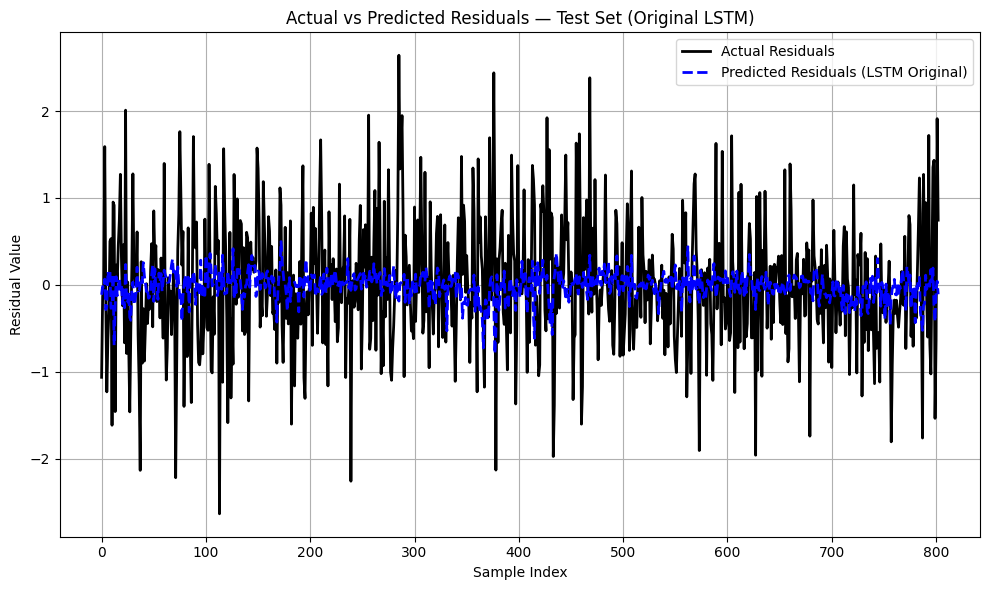

126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

=== Hybrid XGB-LSTM (Original) Performance on WS10M ===

--- Train Metrics ---
RMSE: 0.4399
MSE:  0.1936
MAE:  0.3444
MAPE: 9.4494%
R²:   0.9232

--- Test Metrics ---
RMSE: 0.7281
MSE:  0.5301
MAE:  0.5557
MAPE: 14.9308%
R²:   0.7802


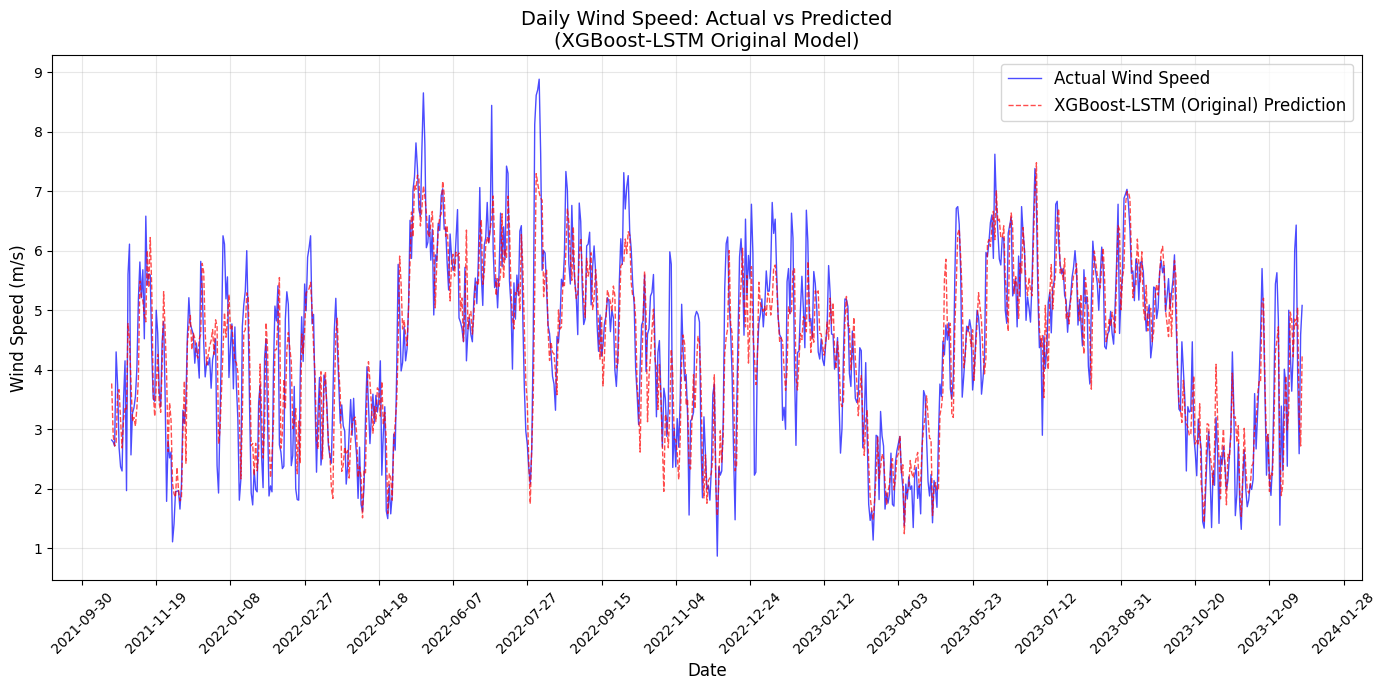

Saved to 'xgb_lstm_df_original.csv'


In [9]:
# =============================================================================
# Section 1 — Original LSTM model
# Default architecture: single LSTM layer (50 units), no dropout.
# No hyperparameter search is performed in this section.
# Scaling is fit on training data only to prevent data leakage.
# =============================================================================

# ── Scaling (fit on training data only — no leakage) ─────────────────────────
scaler_original     = StandardScaler()
X_train_sc_orig     = scaler_original.fit_transform(X_train_res)
X_test_sc_orig      = scaler_original.transform(X_test_res)

# ── Reshape to LSTM format: (samples, timesteps=1, features) ─────────────────
X_train_lstm_orig   = np.expand_dims(X_train_sc_orig, axis=1)
X_test_lstm_orig    = np.expand_dims(X_test_sc_orig,  axis=1)
y_train_lstm_orig   = y_train_res.values.flatten()
y_test_lstm_orig    = y_test_res.values.flatten()

# ── Build LSTM model ──────────────────────────────────────────────────────────
tf.random.set_seed(RANDOM_SEED)
model_orig = Sequential([
    LSTM(50, activation='tanh',
         input_shape=(X_train_lstm_orig.shape[1], X_train_lstm_orig.shape[2])),
    Dense(1)   # Regression output layer
])
model_orig.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Fit on training residuals only (validation_split takes last 20% of train
# set chronologically — no test-set leakage)
history_orig = model_orig.fit(
    X_train_lstm_orig, y_train_lstm_orig,
    epochs=100,
    batch_size=32,
    validation_split=0.2,  # Uses last 20% of training data as validation
    verbose=1,
    shuffle=False           # Preserve temporal order
)

# ── Residual model evaluation ─────────────────────────────────────────────────
y_train_pred_orig = model_orig.predict(X_train_lstm_orig).flatten()
y_test_pred_orig  = model_orig.predict(X_test_lstm_orig).flatten()

print("\n--- Original LSTM Residual Model Evaluation ---")
evaluate(y_train_lstm_orig, y_train_pred_orig, label="Train (LSTM Original)")
evaluate(y_test_lstm_orig,  y_test_pred_orig,  label="Test  (LSTM Original)")

# Plot residual predictions on test set
plt.figure(figsize=(10, 6))
plt.plot(y_test_lstm_orig, label='Actual Residuals',   color='black', linewidth=2)
plt.plot(y_test_pred_orig, label='Predicted Residuals (LSTM Original)',
         color='blue', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Residuals — Test Set (Original LSTM)')
plt.xlabel('Sample Index')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Predict residuals on the FULL dataset ────────────────────────────────────
X_full_sc_orig              = scaler_original.transform(X_res)
X_full_lstm_orig            = np.expand_dims(X_full_sc_orig, axis=1)
full_pred_residuals_original = model_orig.predict(X_full_lstm_orig).flatten()

df_backup['predicted_residuals_lstm_original'] = full_pred_residuals_original

# ── Hybrid prediction: XGB + LSTM residual correction ────────────────────────
df_backup['XGB_LSTM_original'] = (df_backup['Pred_XGB_Optuna'] +
                                   df_backup['predicted_residuals_lstm_original'])

# ── Hybrid model train / test performance ────────────────────────────────────
train_df_orig = df_backup.iloc[:split_index_res].copy()
test_df_orig  = df_backup.iloc[split_index_res:].copy()

print("\n=== Hybrid XGB-LSTM (Original) Performance on WS10M ===")
train_metrics_orig = evaluate_performance(
    train_df_orig['WS10M'], train_df_orig['XGB_LSTM_original'], set_name="Train")
test_metrics_orig  = evaluate_performance(
    test_df_orig['WS10M'],  test_df_orig['XGB_LSTM_original'],  set_name="Test")

# ── Visualise test-set hybrid predictions ────────────────────────────────────
test_df_orig.index = pd.to_datetime(test_df_orig.index)
plt.figure(figsize=(14, 7))
plt.plot(test_df_orig.index, test_df_orig['WS10M'],
         label='Actual Wind Speed', color='blue', alpha=0.7, linewidth=1)
plt.plot(test_df_orig.index, test_df_orig['XGB_LSTM_original'],
         label='XGBoost-LSTM (Original) Prediction',
         color='red', linestyle='--', alpha=0.7, linewidth=1)
plt.title('Daily Wind Speed: Actual vs Predicted\n(XGBoost-LSTM Original Model)',
          fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Wind Speed (m/s)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(20))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save results to CSV
xgb_lstm_df_original = df_backup[fnn_features + ['WS10M', 'XGB_LSTM_original']]
xgb_lstm_df_original.to_csv('xgb_lstm_df_original.csv', index=True)
print("Saved to 'xgb_lstm_df_original.csv'")


## 10. LSTM Residual Correction — Grid Search Hyperparameter Optimisation

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best Parameters (Grid Search):
{'batch_size': 32, 'epochs': 50, 'model__dropout_rate': 0.3, 'model__optimizer': 'adam', 'model__units': 32}

--- Grid Search LSTM Residual Model Evaluation ---
Train (LSTM Grid Search) MSE:  0.2007
Train (LSTM Grid Search) RMSE: 0.4480
Train (LSTM Grid Search) MAE:  0.3517
Train (LSTM Grid Search) MAPE: 2911.83%
Train (LSTM Grid Search) R²:   0.0511
Test  (LSTM Grid Search) MSE:  0.5168
Test  (LSTM Grid Search) RMSE: 0.7189
Test  (LSTM Grid Search) MAE:  0.5474
Test  (LSTM Grid Search) MAPE: 134.94%
Test  (LSTM Grid Search) R²:   0.0198


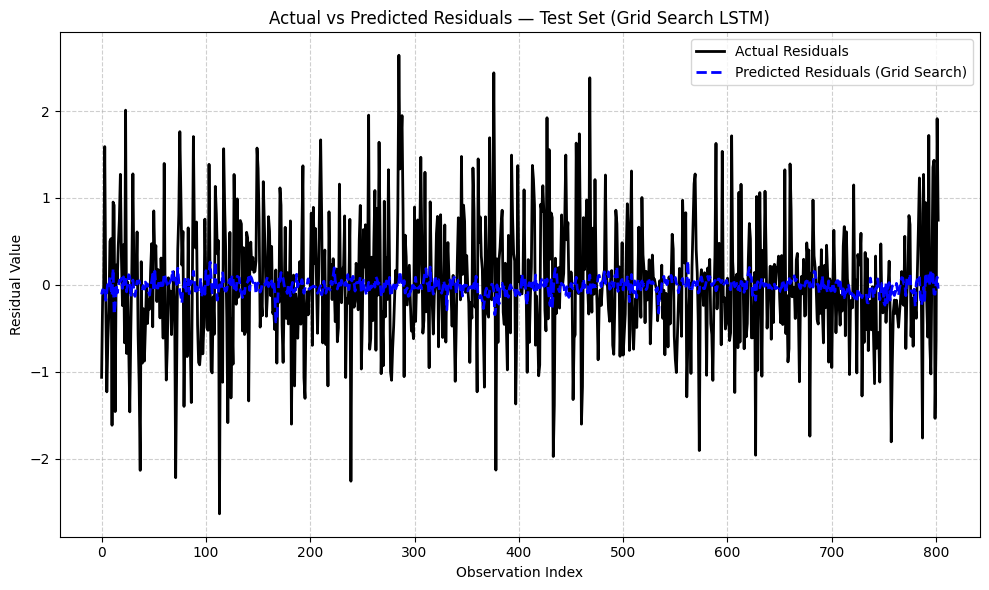


=== Hybrid XGB-LSTM (Grid Search) Performance on WS10M ===

--- Train Metrics ---
RMSE: 0.4480
MSE:  0.2007
MAE:  0.3517
MAPE: 9.6533%
R²:   0.9203

--- Test Metrics ---
RMSE: 0.7189
MSE:  0.5168
MAE:  0.5474
MAPE: 14.7398%
R²:   0.7857


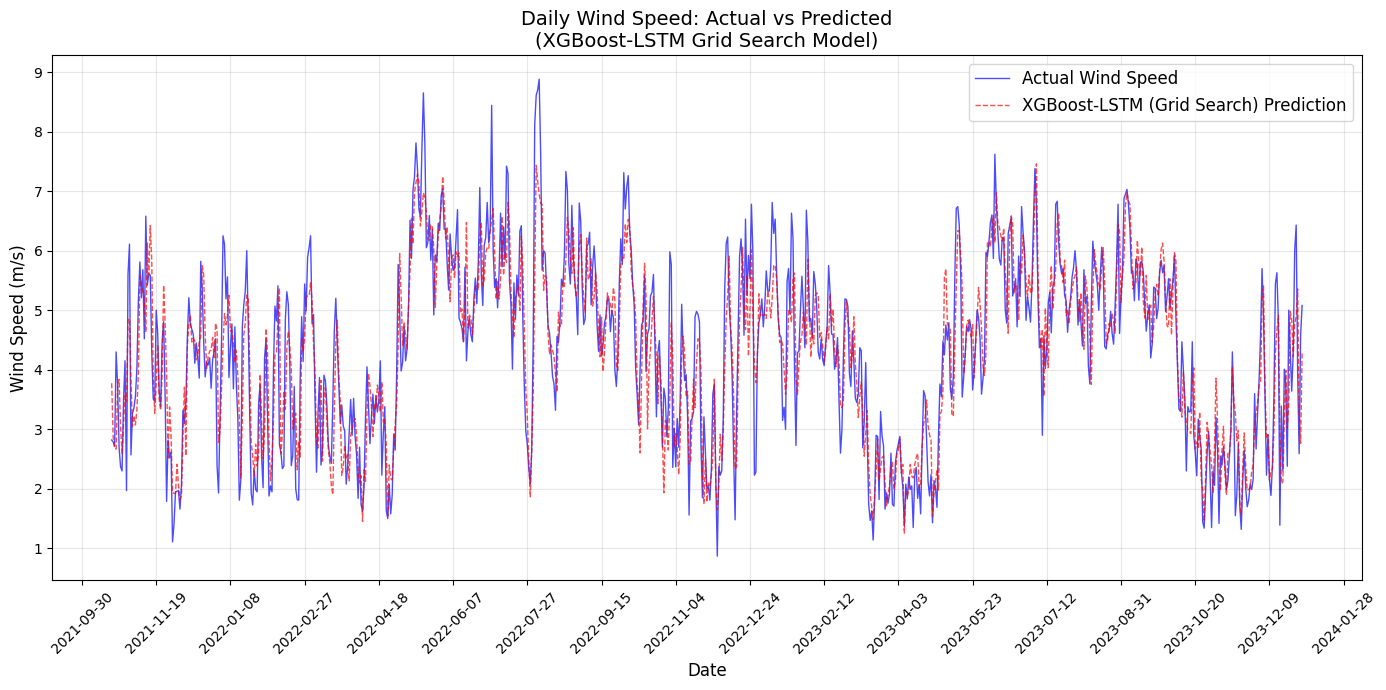

Saved to 'xgb_lstm_df_grid.csv'


In [10]:
# =============================================================================
# Section 2 — Grid Search LSTM
# Exhaustive grid search over the defined parameter grid.
# TimeSeriesSplit (5 folds) is applied exclusively on the training data.
# Scaling is fit on training data only to prevent data leakage.
#
# FIX vs original code:
#   - Replaced cv=3 (standard K-Fold) with TimeSeriesSplit(n_splits=5)
#     to respect temporal ordering during cross-validation.
#   - Removed mid-notebook CSV reload which would have broken the pipeline
#     and required a separate file to exist on disk.
#   - All data is sourced from in-memory objects (X_train_res, y_train_res).
# =============================================================================

# ── Scaling (fit on training data only — no leakage) ─────────────────────────
scaler_grid     = StandardScaler()
X_train_sc_grid = scaler_grid.fit_transform(X_train_res)
X_test_sc_grid  = scaler_grid.transform(X_test_res)

# ── Reshape to LSTM format: (samples, timesteps=1, features) ─────────────────
X_train_lstm_grid = np.expand_dims(X_train_sc_grid, axis=1)
X_test_lstm_grid  = np.expand_dims(X_test_sc_grid,  axis=1)

# ── LSTM model builder (required by KerasRegressor) ──────────────────────────
def build_lstm_grid(units=64, dropout_rate=0.2, optimizer='adam'):
    """Builds and compiles an LSTM model for use in GridSearchCV."""
    n_features = X_train_lstm_grid.shape[2]
    mdl = Sequential([
        LSTM(units, activation='tanh', return_sequences=False,
             input_shape=(1, n_features)),
        Dropout(dropout_rate),
        Dense(1)
    ])
    mdl.compile(optimizer=optimizer, loss='mse')
    return mdl

# ── Wrap Keras model for scikit-learn API ─────────────────────────────────────
regressor_grid = KerasRegressor(
    model=build_lstm_grid, verbose=0, random_state=RANDOM_SEED
)

# ── Parameter grid ────────────────────────────────────────────────────────────
param_grid = {
    "model__units":        [32, 64, 128],
    "model__dropout_rate": [0.1, 0.2, 0.3],
    "model__optimizer":    ['adam', 'rmsprop'],
    "batch_size":          [16, 32],
    "epochs":              [50, 100]
}

# ── Time series cross-validation (training data only) ────────────────────────
tscv_grid = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=regressor_grid,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=tscv_grid,           # TimeSeriesSplit preserves temporal ordering
    verbose=2,
    n_jobs=-1
)

# Fit grid search on training data only
grid_search.fit(X_train_lstm_grid, y_train_res.values.flatten())

best_model_grid = grid_search.best_estimator_
print("\nBest Parameters (Grid Search):")
print(grid_search.best_params_)

# ── Residual model evaluation ─────────────────────────────────────────────────
y_train_pred_grid = best_model_grid.predict(X_train_lstm_grid).flatten()
y_test_pred_grid  = best_model_grid.predict(X_test_lstm_grid).flatten()

print("\n--- Grid Search LSTM Residual Model Evaluation ---")
evaluate(y_train_res.values, y_train_pred_grid, label="Train (LSTM Grid Search)")
evaluate(y_test_res.values,  y_test_pred_grid,  label="Test  (LSTM Grid Search)")

# Plot residual predictions on test set
plt.figure(figsize=(10, 6))
plt.plot(y_test_res.values, label='Actual Residuals',   color='black', linewidth=2)
plt.plot(y_test_pred_grid,  label='Predicted Residuals (Grid Search)',
         color='blue', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Residuals — Test Set (Grid Search LSTM)')
plt.xlabel('Observation Index')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── Predict residuals on the FULL dataset ────────────────────────────────────
X_full_sc_grid          = scaler_grid.transform(X_res)
X_full_lstm_grid        = np.expand_dims(X_full_sc_grid, axis=1)
full_pred_residuals_grid = best_model_grid.predict(X_full_lstm_grid).flatten()

df_backup['predicted_residuals_lstm_grid'] = full_pred_residuals_grid

# ── Hybrid prediction: XGB + LSTM residual correction ────────────────────────
df_backup['XGB_LSTM_grid'] = (df_backup['Pred_XGB_Optuna'] +
                               df_backup['predicted_residuals_lstm_grid'])

# ── Hybrid model train / test performance ────────────────────────────────────
train_df_grid = df_backup.iloc[:split_index_res].copy()
test_df_grid  = df_backup.iloc[split_index_res:].copy()

print("\n=== Hybrid XGB-LSTM (Grid Search) Performance on WS10M ===")
train_metrics_grid = evaluate_performance(
    train_df_grid['WS10M'], train_df_grid['XGB_LSTM_grid'], set_name="Train")
test_metrics_grid  = evaluate_performance(
    test_df_grid['WS10M'],  test_df_grid['XGB_LSTM_grid'],  set_name="Test")

# ── Visualise test-set hybrid predictions ────────────────────────────────────
test_df_grid.index = pd.to_datetime(test_df_grid.index)
plt.figure(figsize=(14, 7))
plt.plot(test_df_grid.index, test_df_grid['WS10M'],
         label='Actual Wind Speed', color='blue', alpha=0.7, linewidth=1)
plt.plot(test_df_grid.index, test_df_grid['XGB_LSTM_grid'],
         label='XGBoost-LSTM (Grid Search) Prediction',
         color='red', linestyle='--', alpha=0.7, linewidth=1)
plt.title('Daily Wind Speed: Actual vs Predicted\n(XGBoost-LSTM Grid Search Model)',
          fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Wind Speed (m/s)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(20))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save results to CSV
xgb_lstm_df_grid = df_backup[fnn_features + ['WS10M', 'XGB_LSTM_grid']]
xgb_lstm_df_grid.to_csv('xgb_lstm_df_grid.csv', index=True)
print("Saved to 'xgb_lstm_df_grid.csv'")


## 11. LSTM Residual Correction — Randomized Search Hyperparameter Optimisation

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END batch_size=54, epochs=101, model__dropout_rate=0.38521429192297485, model__learning_rate=0.006687945476302646, model__units=40; total time=  12.5s
[CV] END batch_size=54, epochs=101, model__dropout_rate=0.38521429192297485, model__learning_rate=0.006687945476302646, model__units=40; total time=  13.4s
[CV] END batch_size=54, epochs=101, model__dropout_rate=0.38521429192297485, model__learning_rate=0.006687945476302646, model__units=40; total time=  16.3s
[CV] END batch_size=54, epochs=101, model__dropout_rate=0.38521429192297485, model__learning_rate=0.006687945476302646, model__units=40; total time=  19.1s
[CV] END batch_size=54, epochs=101, model__dropout_rate=0.38521429192297485, model__learning_rate=0.006687945476302646, model__units=40; total time=  23.3s
[CV] END batch_size=54, epochs=132, model__dropout_rate=0.12999247474540088, model__learning_rate=0.004233240027692805, model__units=136; total time=  15.2s
[C

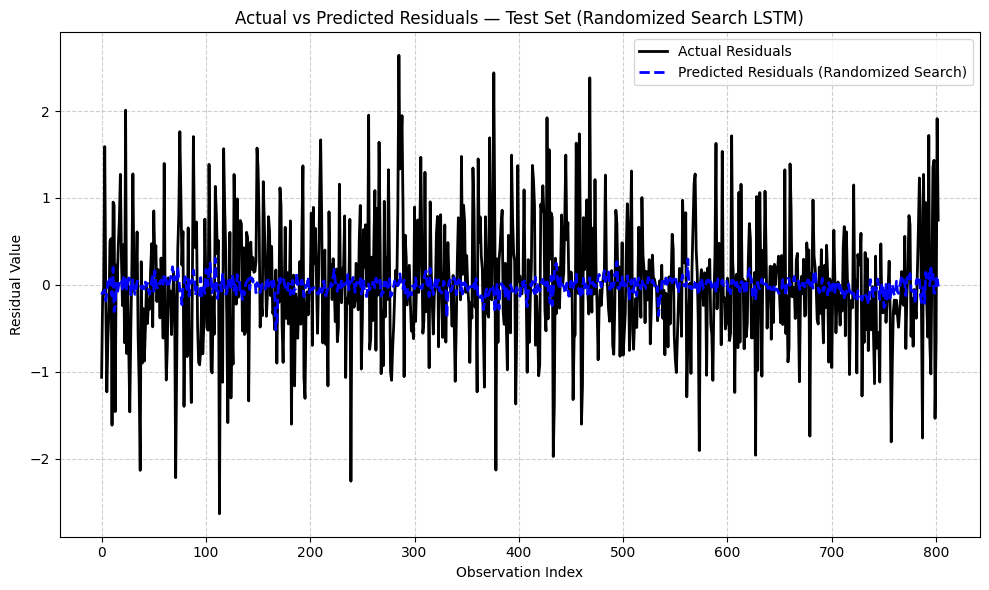


=== Hybrid XGB-LSTM (Randomized Search) Performance on WS10M ===

--- Train Metrics ---
RMSE: 0.4487
MSE:  0.2013
MAE:  0.3523
MAPE: 9.6781%
R²:   0.9201

--- Test Metrics ---
RMSE: 0.7187
MSE:  0.5165
MAE:  0.5471
MAPE: 14.7457%
R²:   0.7858


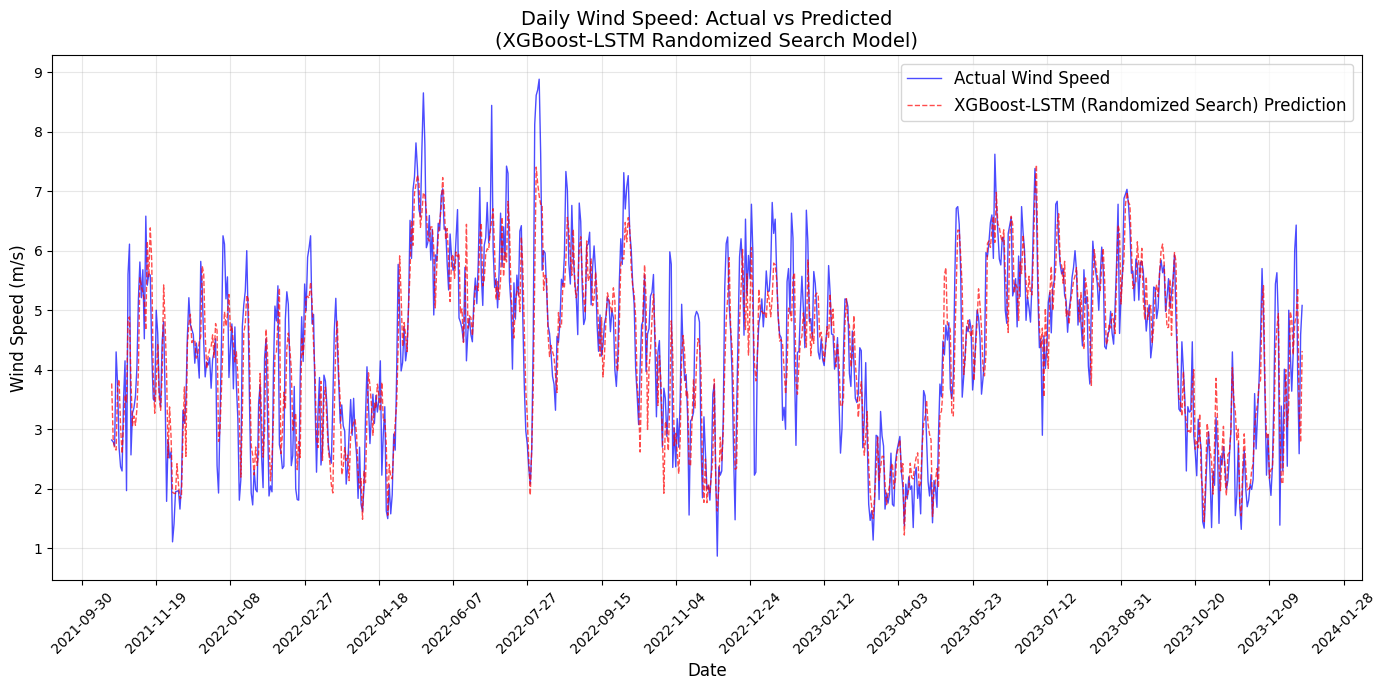

Saved to 'xgb_lstm_df_random.csv'


In [11]:
# =============================================================================
# Section 3 — Randomized Search LSTM
# Random sampling over hyperparameter distributions (10 iterations).
# TimeSeriesSplit (5 folds) is applied exclusively on training data.
# Scaling is fit on training data only to prevent data leakage.
# =============================================================================

# ── Scaling (fit on training data only — no leakage) ─────────────────────────
scaler_random     = StandardScaler()
X_train_sc_rand   = scaler_random.fit_transform(X_train_res)
X_test_sc_rand    = scaler_random.transform(X_test_res)

# ── Reshape to LSTM format: (samples, timesteps=1, features) ─────────────────
X_train_lstm_rand = np.expand_dims(X_train_sc_rand, axis=1)
X_test_lstm_rand  = np.expand_dims(X_test_sc_rand,  axis=1)

# ── LSTM model builder (required by KerasRegressor) ──────────────────────────
def create_lstm_random(units=50, dropout_rate=0.2, learning_rate=0.001):
    """Builds and compiles an LSTM model for use in RandomizedSearchCV."""
    n_features = X_train_lstm_rand.shape[2]
    mdl = Sequential([
        LSTM(units=units, input_shape=(1, n_features)),
        Dropout(dropout_rate),
        Dense(1)   # Regression output
    ])
    mdl.compile(loss='mse', optimizer=Adam(learning_rate=learning_rate))
    return mdl

# ── Wrap Keras model for scikit-learn API ─────────────────────────────────────
lstm_regressor_rand = KerasRegressor(
    model=create_lstm_random, verbose=0, random_state=RANDOM_SEED
)

# ── Hyperparameter distributions ─────────────────────────────────────────────
param_dist = {
    'model__units':         randint(20, 151),
    'model__dropout_rate':  uniform(0.1, 0.3),
    'model__learning_rate': uniform(1e-4, 9e-3),
    'batch_size':           randint(16, 65),
    'epochs':               randint(50, 151)
}

# ── Time series cross-validation (training data only) ────────────────────────
tscv_rand = TimeSeriesSplit(n_splits=5)

random_search = RandomizedSearchCV(
    estimator=lstm_regressor_rand,
    param_distributions=param_dist,
    n_iter=10,
    scoring='neg_mean_squared_error',
    cv=tscv_rand,           # TimeSeriesSplit preserves temporal ordering
    random_state=RANDOM_SEED,
    verbose=2,
    n_jobs=1                # Sequential to avoid TF/Keras multiprocessing issues
)

# Fit randomized search on training data only
random_search.fit(X_train_lstm_rand, y_train_res.values.flatten())

best_model_rand = random_search.best_estimator_
print("\nBest Parameters (Randomized Search):")
print(random_search.best_params_)

# ── Residual model evaluation ─────────────────────────────────────────────────
y_train_pred_rand = best_model_rand.predict(X_train_lstm_rand).flatten()
y_test_pred_rand  = best_model_rand.predict(X_test_lstm_rand).flatten()

print("\n--- Randomized Search LSTM Residual Model Evaluation ---")
evaluate(y_train_res.values, y_train_pred_rand, label="Train (LSTM Randomized Search)")
evaluate(y_test_res.values,  y_test_pred_rand,  label="Test  (LSTM Randomized Search)")

# Plot residual predictions on test set
plt.figure(figsize=(10, 6))
plt.plot(y_test_res.values, label='Actual Residuals',   color='black', linewidth=2)
plt.plot(y_test_pred_rand,  label='Predicted Residuals (Randomized Search)',
         color='blue', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Residuals — Test Set (Randomized Search LSTM)')
plt.xlabel('Observation Index')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── Predict residuals on the FULL dataset ────────────────────────────────────
X_full_sc_rand           = scaler_random.transform(X_res)
X_full_lstm_rand         = np.expand_dims(X_full_sc_rand, axis=1)
full_pred_residuals_rand  = best_model_rand.predict(X_full_lstm_rand).flatten()

df_backup['predicted_residuals_lstm_random'] = full_pred_residuals_rand

# ── Hybrid prediction: XGB + LSTM residual correction ────────────────────────
df_backup['XGB_LSTM_random'] = (df_backup['Pred_XGB_Optuna'] +
                                 df_backup['predicted_residuals_lstm_random'])

# ── Hybrid model train / test performance ────────────────────────────────────
train_df_rand = df_backup.iloc[:split_index_res].copy()
test_df_rand  = df_backup.iloc[split_index_res:].copy()

print("\n=== Hybrid XGB-LSTM (Randomized Search) Performance on WS10M ===")
train_metrics_rand = evaluate_performance(
    train_df_rand['WS10M'], train_df_rand['XGB_LSTM_random'], set_name="Train")
test_metrics_rand  = evaluate_performance(
    test_df_rand['WS10M'],  test_df_rand['XGB_LSTM_random'],  set_name="Test")

# ── Visualise test-set hybrid predictions ────────────────────────────────────
test_df_rand.index = pd.to_datetime(test_df_rand.index)
plt.figure(figsize=(14, 7))
plt.plot(test_df_rand.index, test_df_rand['WS10M'],
         label='Actual Wind Speed', color='blue', alpha=0.7, linewidth=1)
plt.plot(test_df_rand.index, test_df_rand['XGB_LSTM_random'],
         label='XGBoost-LSTM (Randomized Search) Prediction',
         color='red', linestyle='--', alpha=0.7, linewidth=1)
plt.title('Daily Wind Speed: Actual vs Predicted\n(XGBoost-LSTM Randomized Search Model)',
          fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Wind Speed (m/s)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(20))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save results to CSV
xgb_lstm_df_random = df_backup[fnn_features + ['WS10M', 'XGB_LSTM_random']]
xgb_lstm_df_random.to_csv('xgb_lstm_df_random.csv', index=True)
print("Saved to 'xgb_lstm_df_random.csv'")


## 12. LSTM Residual Correction — Optuna Bayesian Optimisation


Best Trial:
FrozenTrial(number=3, state=<TrialState.COMPLETE: 1>, values=[0.22869701827700423], datetime_start=datetime.datetime(2026, 3, 12, 6, 58, 45, 900504), datetime_complete=datetime.datetime(2026, 3, 12, 7, 0, 27, 668652), params={'units': 38, 'dropout_rate': 0.21685785941408728, 'learning_rate': 0.0005404103854647331, 'batch_size': 32, 'epochs': 101}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'units': IntDistribution(high=150, log=False, low=20, step=1), 'dropout_rate': FloatDistribution(high=0.5, log=False, low=0.1, step=None), 'learning_rate': FloatDistribution(high=0.01, log=True, low=0.0001, step=None), 'batch_size': CategoricalDistribution(choices=(16, 32, 64)), 'epochs': IntDistribution(high=150, log=False, low=50, step=1)}, trial_id=3, value=None)

Best Parameters (Optuna):
{'units': 38, 'dropout_rate': 0.21685785941408728, 'learning_rate': 0.0005404103854647331, 'batch_size': 32, 'epochs': 101}
Epoch 1/101
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 5m

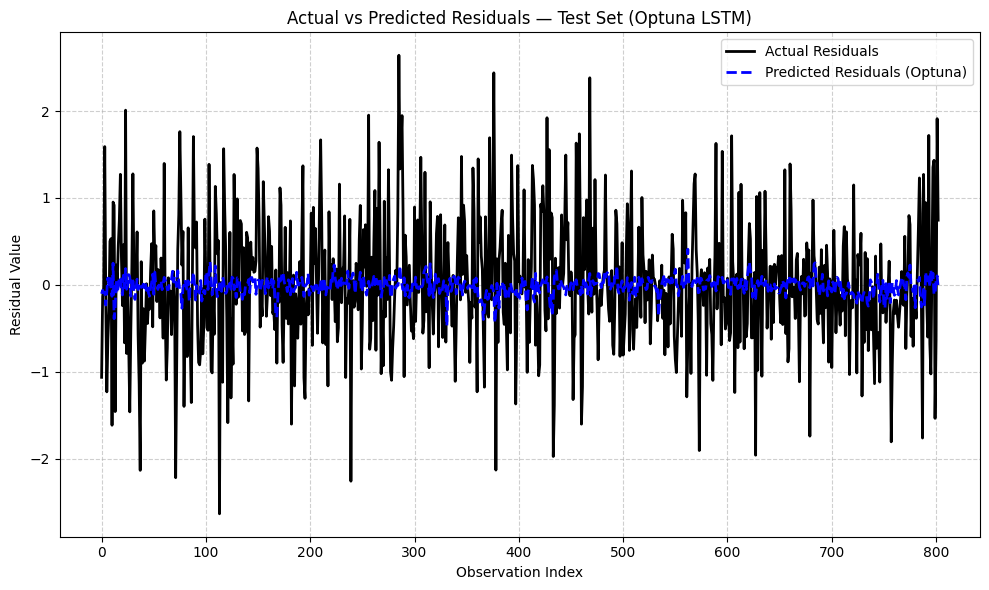

126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=== Hybrid XGB-LSTM (Optuna) Performance on WS10M ===

--- Train Metrics ---
RMSE: 0.4459
MSE:  0.1988
MAE:  0.3498
MAPE: 9.5879%
R²:   0.9211

--- Test Metrics ---
RMSE: 0.7186
MSE:  0.5164
MAE:  0.5482
MAPE: 14.7551%
R²:   0.7859


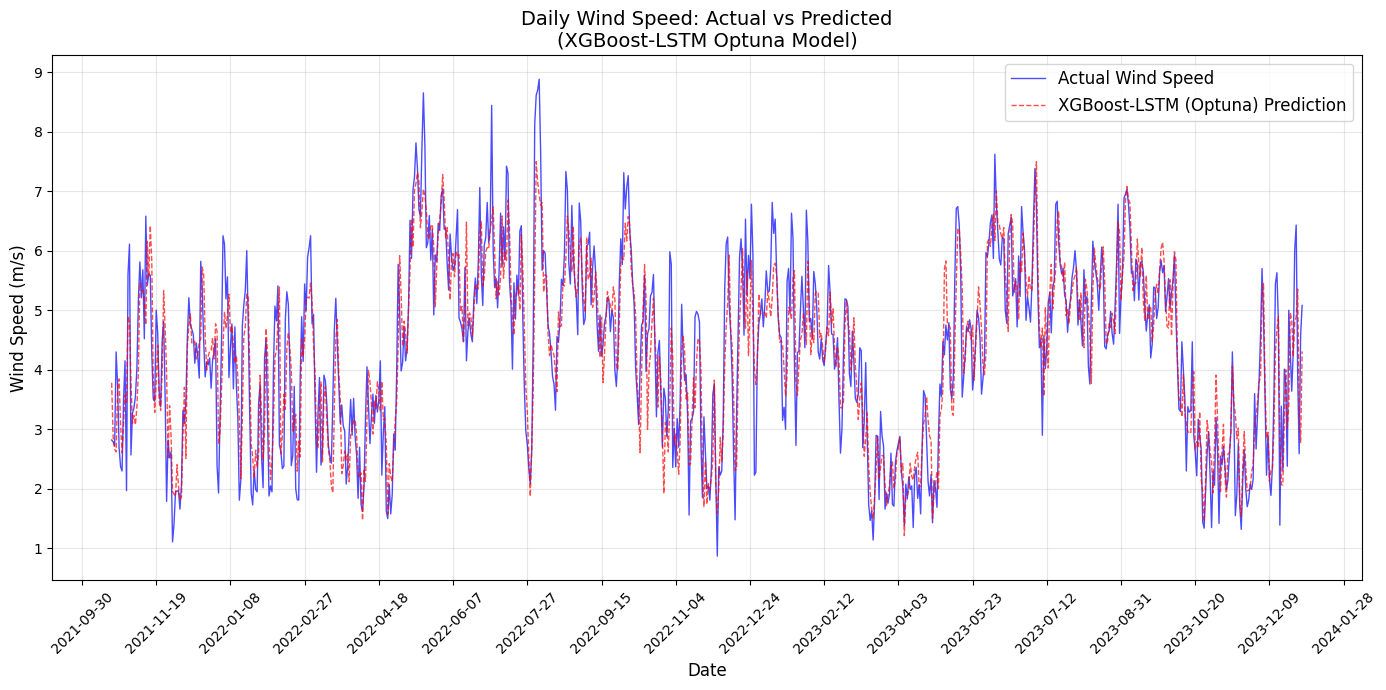

Saved to 'xgb_lstm_df_optuna.csv'


In [12]:
# =============================================================================
# Section 4 — Optuna LSTM
# Bayesian (TPE) hyperparameter search over architecture and training params.
# TimeSeriesSplit (5 folds) is applied exclusively on training data.
# Scaling is fit on training data only to prevent data leakage.
#
# FIXES vs original code:
#   1. suggest_loguniform() is DEPRECATED in Optuna ≥ 3.x.
#      Replaced with suggest_float('learning_rate', ..., log=True).
#   2. The original code built the LSTM model ONCE in create_lstm_model()
#      and called model.fit() multiple times within the CV loop — this
#      accumulates gradients across folds (weight leakage between folds).
#      Fixed: the model is rebuilt fresh for every fold inside the objective.
#   3. Pre-scaled numpy array (X_train_sc_opt) is used throughout the
#      objective to ensure the LSTM sees the same scaled input as the
#      final model fitted after the study.
# =============================================================================

# ── Scaling (fit on training data only — no leakage) ─────────────────────────
scaler_optuna     = StandardScaler()
X_train_sc_opt    = scaler_optuna.fit_transform(X_train_res)
X_test_sc_opt     = scaler_optuna.transform(X_test_res)

# ── Reshape to LSTM format: (samples, timesteps=1, features) ─────────────────
X_train_lstm_opt  = np.expand_dims(X_train_sc_opt, axis=1)
X_test_lstm_opt   = np.expand_dims(X_test_sc_opt,  axis=1)
n_features_opt    = X_train_lstm_opt.shape[2]

# ── Optuna objective function ─────────────────────────────────────────────────
def lstm_objective(trial):
    """
    Objective for Optuna Bayesian optimisation.
    A FRESH model is rebuilt for every cross-validation fold to prevent
    gradient / weight accumulation across folds (data leakage).
    """
    units         = trial.suggest_int('units', 20, 150)
    dropout_rate  = trial.suggest_float('dropout_rate', 0.1, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size    = trial.suggest_categorical('batch_size', [16, 32, 64])
    epochs        = trial.suggest_int('epochs', 50, 150)

    tscv       = TimeSeriesSplit(n_splits=5)
    mse_scores = []

    for train_idx, val_idx in tscv.split(X_train_lstm_opt):
        # Use pre-scaled numpy slices (no double-scaling / leakage)
        X_t = X_train_lstm_opt[train_idx]
        X_v = X_train_lstm_opt[val_idx]
        y_t = y_train_res.values[train_idx]
        y_v = y_train_res.values[val_idx]

        # Build a FRESH model for each fold to prevent weight accumulation
        tf.random.set_seed(RANDOM_SEED)
        fold_model = Sequential([
            LSTM(units=units, input_shape=(1, n_features_opt)),
            Dropout(dropout_rate),
            Dense(1)
        ])
        fold_model.compile(loss='mse',
                           optimizer=Adam(learning_rate=learning_rate))
        fold_model.fit(X_t, y_t, epochs=epochs, batch_size=batch_size,
                       verbose=0, shuffle=False)

        preds = fold_model.predict(X_v, verbose=0).flatten()
        mse_scores.append(mean_squared_error(y_v, preds))

    return np.mean(mse_scores)

# ── Create and run Optuna study ───────────────────────────────────────────────
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
# Max 30 trials or 10 minutes, whichever comes first
study.optimize(lstm_objective, n_trials=30, timeout=600)

print("\nBest Trial:")
print(study.best_trial)
print("\nBest Parameters (Optuna):")
print(study.best_params)

# ── Refit final model on full training data with best parameters ─────────────
best_params_opt = study.best_params

tf.random.set_seed(RANDOM_SEED)
final_model_opt = Sequential([
    LSTM(units=best_params_opt['units'], input_shape=(1, n_features_opt)),
    Dropout(best_params_opt['dropout_rate']),
    Dense(1)
])
final_model_opt.compile(
    loss='mse',
    optimizer=Adam(learning_rate=best_params_opt['learning_rate'])
)
final_model_opt.fit(
    X_train_lstm_opt, y_train_res.values.flatten(),
    epochs=best_params_opt['epochs'],
    batch_size=best_params_opt['batch_size'],
    verbose=1,
    shuffle=False   # Preserve temporal order
)

# ── Residual model evaluation ─────────────────────────────────────────────────
y_train_pred_opt = final_model_opt.predict(X_train_lstm_opt).flatten()
y_test_pred_opt  = final_model_opt.predict(X_test_lstm_opt).flatten()

print("\n--- Optuna LSTM Residual Model Evaluation ---")
evaluate(y_train_res.values, y_train_pred_opt, label="Train (LSTM Optuna)")
evaluate(y_test_res.values,  y_test_pred_opt,  label="Test  (LSTM Optuna)")

# Plot residual predictions on test set
plt.figure(figsize=(10, 6))
plt.plot(y_test_res.values, label='Actual Residuals', color='black', linewidth=2)
plt.plot(y_test_pred_opt,   label='Predicted Residuals (Optuna)',
         color='blue', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Residuals — Test Set (Optuna LSTM)')
plt.xlabel('Observation Index')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── Predict residuals on the FULL dataset ────────────────────────────────────
X_full_sc_opt             = scaler_optuna.transform(X_res)
X_full_lstm_opt           = np.expand_dims(X_full_sc_opt, axis=1)
full_pred_residuals_optuna = final_model_opt.predict(X_full_lstm_opt).flatten()

df_backup['predicted_residuals_lstm_optuna'] = full_pred_residuals_optuna

# ── Hybrid prediction: XGB + LSTM residual correction ────────────────────────
df_backup['XGB_LSTM_optuna'] = (df_backup['Pred_XGB_Optuna'] +
                                 df_backup['predicted_residuals_lstm_optuna'])

# ── Hybrid model train / test performance ────────────────────────────────────
train_df_opt = df_backup.iloc[:split_index_res].copy()
test_df_opt  = df_backup.iloc[split_index_res:].copy()

print("\n=== Hybrid XGB-LSTM (Optuna) Performance on WS10M ===")
train_metrics_opt = evaluate_performance(
    train_df_opt['WS10M'], train_df_opt['XGB_LSTM_optuna'], set_name="Train")
test_metrics_opt  = evaluate_performance(
    test_df_opt['WS10M'],  test_df_opt['XGB_LSTM_optuna'],  set_name="Test")

# ── Visualise test-set hybrid predictions ────────────────────────────────────
test_df_opt.index = pd.to_datetime(test_df_opt.index)
plt.figure(figsize=(14, 7))
plt.plot(test_df_opt.index, test_df_opt['WS10M'],
         label='Actual Wind Speed', color='blue', alpha=0.7, linewidth=1)
plt.plot(test_df_opt.index, test_df_opt['XGB_LSTM_optuna'],
         label='XGBoost-LSTM (Optuna) Prediction',
         color='red', linestyle='--', alpha=0.7, linewidth=1)
plt.title('Daily Wind Speed: Actual vs Predicted\n(XGBoost-LSTM Optuna Model)',
          fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Wind Speed (m/s)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(20))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save results to CSV
xgb_lstm_df_optuna = df_backup[fnn_features + ['WS10M', 'XGB_LSTM_optuna']]
xgb_lstm_df_optuna.to_csv('xgb_lstm_df_optuna.csv', index=True)
print("Saved to 'xgb_lstm_df_optuna.csv'")


## 13. Comprehensive Performance Comparison Across All Methods

In [13]:
# =============================================================================
# Summary comparison of all four XGBoost-LSTM hybrid model variants.
# Method labels: "Original Model", "Grid Search", "Randomized Search", "Optuna"
# =============================================================================

actual = df_backup['WS10M']

# Map human-readable method names to dataframe column names
methods_map = {
    'Original Model':    'XGB_LSTM_original',
    'Grid Search':       'XGB_LSTM_grid',
    'Randomized Search': 'XGB_LSTM_random',
    'Optuna':            'XGB_LSTM_optuna'
}

split_idx    = int(0.8 * len(df_backup))
train_actual = actual.iloc[:split_idx]
test_actual  = actual.iloc[split_idx:]

results = []
for method_name, col_name in methods_map.items():
    pred       = df_backup[col_name]
    train_pred = pred.iloc[:split_idx]
    test_pred  = pred.iloc[split_idx:]

    results.append({
        'Method':         method_name,
        'Train MSE':      mean_squared_error(train_actual, train_pred),
        'Test MSE':       mean_squared_error(test_actual,  test_pred),
        'Train MAE':      mean_absolute_error(train_actual, train_pred),
        'Test MAE':       mean_absolute_error(test_actual,  test_pred),
        'Train RMSE':     np.sqrt(mean_squared_error(train_actual, train_pred)),
        'Test RMSE':      np.sqrt(mean_squared_error(test_actual,  test_pred)),
        'Train MAPE (%)': np.mean(np.abs((train_actual - train_pred) / train_actual)) * 100,
        'Test MAPE (%)':  np.mean(np.abs((test_actual  - test_pred)  / test_actual))  * 100,
        'Train R²':       r2_score(train_actual, train_pred),
        'Test R²':        r2_score(test_actual,  test_pred)
    })

results_df = pd.DataFrame(results)
print("\n=== XGBoost-LSTM Hybrid Model Performance Comparison ===")
print(results_df.to_string(index=False))

# Save the full comparison to CSV
results_df.to_csv('xgb_lstm_all_models_performance.csv', index=False)
print("\nSaved to 'xgb_lstm_all_models_performance.csv'")

# ── Plotly summary table ──────────────────────────────────────────────────────
numeric_cols = [c for c in results_df.columns if c != 'Method']
display_df   = results_df.copy()
for col in numeric_cols:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.6f}")

fig_summary = go.Figure(go.Table(
    header=dict(
        values=[f'<b>{c}</b>' for c in results_df.columns],
        fill_color='steelblue',
        font=dict(color='white', size=11),
        align='center'
    ),
    cells=dict(
        values=[display_df[c] for c in display_df.columns],
        fill_color=[['lightcyan' if i % 2 == 0 else 'white'
                     for i in range(len(display_df))]],
        align='center'
    )
))
fig_summary.update_layout(
    title="XGBoost-LSTM Hybrid Models — Full Performance Comparison",
    template="plotly_white",
    height=300
)
fig_summary.show()



=== XGBoost-LSTM Hybrid Model Performance Comparison ===
           Method  Train MSE  Test MSE  Train MAE  Test MAE  Train RMSE  Test RMSE  Train MAPE (%)  Test MAPE (%)  Train R²  Test R²
   Original Model   0.193550  0.530120   0.344413  0.555696    0.439943   0.728093        9.449416      14.930770  0.923173 0.780165
      Grid Search   0.200724  0.516778   0.351687  0.547424    0.448023   0.718873        9.653300      14.739841  0.920325 0.785697
Randomized Search   0.201349  0.516536   0.352301  0.547111    0.448720   0.718705        9.678073      14.745668  0.920077 0.785798
           Optuna   0.198843  0.516391   0.349834  0.548168    0.445918   0.718603        9.587948      14.755135  0.921072 0.785858

Saved to 'xgb_lstm_all_models_performance.csv'
